|<img style="float:left;" src="./images/usherb_transp.gif" width=90% height=90%> |<big>Pierre Proulx, ing, professeur</big>|
|:---|:---|
|Département de génie chimique et de génie biotechnologique |** GCH200-Phénomènes d'échanges I **|

### Problème 2B6


><img src='./images/Chap-2-Prob-2B6.png'>


In [1]:
#
# Pierre Proulx
#
# Préparation de l'affichage et des outils de calcul symbolique
#
import sympy as sp
from IPython.display import *
sp.init_printing(use_latex=True)
%matplotlib inline

In [2]:
# définitions
r,L,mu,R,rho,g,alpha=sp.symbols('r,L,mu,R,rho,g,alpha')
v_z=sp.Function('v_z')(r)
tau_rz=sp.Function('tau_rz')(r)

In [3]:
eq1=r*tau_rz
eq2=-1/r*eq1.diff(r)+rho*g
display(eq2)

In [4]:
eq3=sp.dsolve(eq2)
display(eq3)      

In [5]:
eq4=eq3.subs(tau_rz,-mu*v_z.diff(r))
display(eq4)

In [6]:
v_z=sp.dsolve(eq4)
display('Profil de vitesse général, avant de trouver les constantes C1 et C2',v_z)

'Profil de vitesse général, avant de trouver les constantes C1 et C2'

In [7]:
v_z=v_z.rhs
condition_1=sp.Eq(v_z.subs(r,R),0)
condition_2=sp.Eq(v_z.diff(r).subs(r,alpha*R),0)
display('conditions aux limites',condition_1,condition_2)
constantes=sp.solve([condition_1,condition_2], sp.symbols('C1,C2'))
display('constantes',constantes)

'conditions aux limites'

'constantes'

In [8]:
v_z=v_z.subs(constantes)
display(v_z)

In [9]:
#
# Débit volumétrique
#
debit=sp.integrate(v_z*r,(r,R,alpha*R))
display(debit.simplify())

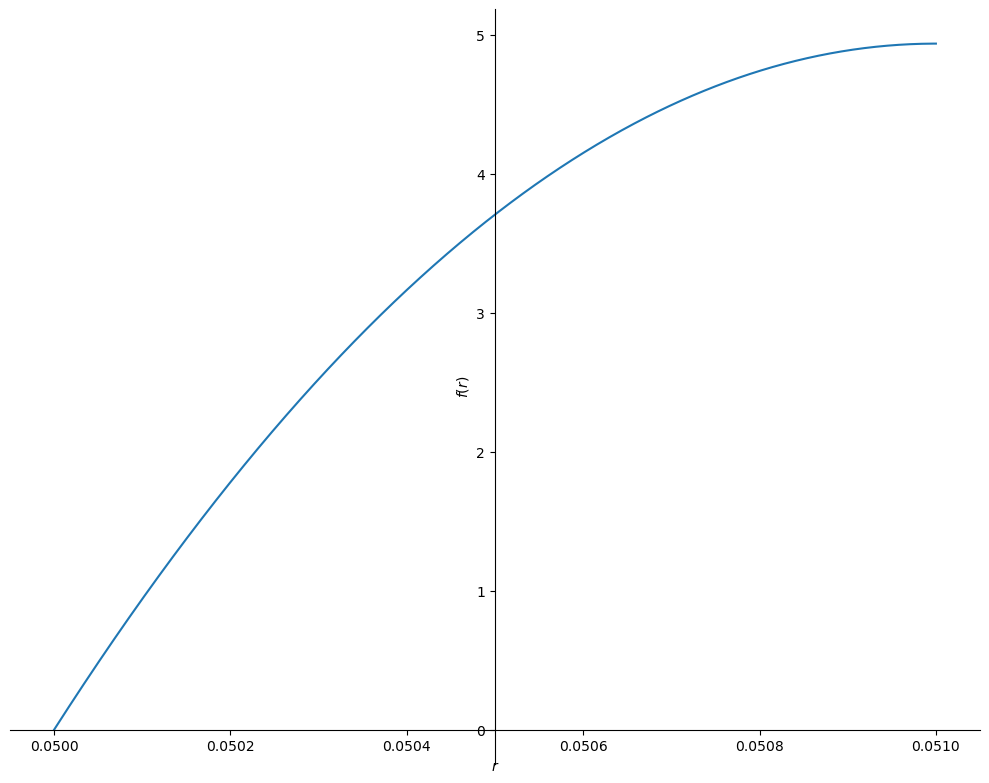

In [10]:
#
#  Tracer le profil pour des valeurs quelconques (mais réalistes)
#
dictionnaire={'rho':1000,'g':9.81, 'mu':0.001,'R':0.05,'alpha':1.02}
v_z=v_z.subs(dictionnaire)
alpha=alpha.subs(dictionnaire)
R=R.subs(dictionnaire)
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = 10,8  
sp.plot(v_z,(r,R,alpha*R));